<a href="https://colab.research.google.com/github/DDaku23/p1-machine/blob/main/202620/Pr%C3%A1cticas/P1_Exploraci%C3%B3n%20y%20calidad%20de%20datos/P1_ManipulacionExploracionCalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![BannerAA_Notebooks.png](attachment:7714036d-7fc6-4942-9dc1-d9fea4370259.png)


# Manipulación, exploración y calidad de datos

En este notebook tutorial aprenderás cómo explorar un conjunto de datos con la ayuda de la librería Pandas. También usaremos librerías de visualización de datos muy útiles para conocer los datos, como Matplotlib y Seaborn.

En este notebooks verás cómo:
1. Importar las librerías que usaremos.
2. Cargar un conjunto de datos.
3. Describir los datos.
4. Manipular los datos.
5. Generar distintos tipos de visualizaciones.
6. Verificar la calidad de datos.

El conjunto de datos que usaremos a lo largo de este notebook recopila información sobre la venta de inmuebles, la cual incluye variables que describen las características principales de cada uno y el precio final de venta. El análisis de estos datos puede ser útil para comprender los factores que influyen en el valor de mercado de los inmuebles y para construir modelos predictivos para este sector.

## 1. Importar las librerías que usaremos

Como primer paso importamos las librerías con las que vamos a trabajar. Veamos la función de cada una:

* Pandas: nos permite cargar, explorar y manipular grandes conjuntos de datos.
* Matplotlib: nos ayuda a crear visualizaciones y gráficos personalizados.
* Seaborn: facilita la creación de gráficos estadísticos.



In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Luego, revisamos las versiones de las librerías a usar. Esto es útil para asegurar la compatibilidad del código y reproducibilidad de resultados en otros entornos, localmente o en Google Colab, evitando errores inesperados. Además, sirve para revisar la documentación adeduada porque puede cambiar con el tiempo.

In [14]:
from importlib.metadata import version
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Seaborn: {version('seaborn')}")

Versión de Pandas: 2.2.3
Versión de Matplotlib: 3.10.0
Versión de Seaborn: 0.13.2


## 2. Cargar un conjunto de datos
Los datos que usamos en proyectos de ML pueden tener diferentes representaciones:

| Categoría | Descripción | Ejemplos |
|-----------|-------------|---------|
| **Tabulares (estructurados)** | Estructura definida en filas y columnas. Fáciles de procesar. | CSV, Excel |
| **No tabulares (no estructurados)** | Formato libre. Representan el 80-90% de los datos del mundo. Requieren transformación. | Imágenes, audio, texto |
| **Semi-estructurados** | Mezclan elementos tabulares y no tabulares. | XML, JSON, correos |

En este notebook trabajamos con datos **tabulares**.

A continuación, vamos a cargar el conjunto de datos que utilizaremos. Este archivo se encuentra en formato Excel, que al igual que el CSV, es un formato ampliamente utilizado para almacenar datos tabulares. Para leerlo usaremos la función de Pandas `read_excel()`.
Es importante aclarar que al interior de los paréntesis se especifica la ruta en la cual se encuentra el conjunto de datos, en este caso localizaremos el archivo en el subdirectorio `data`, que se encuentra en el mismo directorio de este notebook. Si el conjunto tiene una ubicación diferente, puedes cambiar la ruta al interior de los paréntesis o modificar la ubicación del archivo.

En caso de que el conjunto de datos se encuentre en formato CSV, usaremos la función `read_csv()`.


In [15]:
datos_inmuebles = pd.read_excel('./Venta_Inmuebles.xlsx', )

Con esta sentencia, el archivo Excel se transforma en un DataFrame, una estructura compuesta de filas y columnas. La librería de Pandas, nos ayuda a estructurar los datos de esta forma para facilitar su exploración, manipulación y análisis de los datos.

Una buena práctica es trabajar siempre con una copia de los datos:

In [16]:
data = datos_inmuebles.copy()

Para tener una primera visión de los datos usaremos la función head(), la cual nos permite ver los primeros cinco registros del DataFrame:

In [17]:
data.head()

,Id,Fecha,Precio,Cuartos,Baños,AreaHabitable,AreaLote,Pisos,FrenteMar,Vista,...,Calificación,AreaSuperior,AreaBase,Años,Renovación,CodigoPostal,Latitud,Longitud,AreaHabitable15,AreaLote15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,NO,0,...,7.0,1180,0,1955,0,98178,475112.0,-122257.0,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,NO,0,...,7.0,2170,400,1951,1991,98125,47721.0,-122319.0,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,NO,0,...,6.0,770,0,1933,0,98028,477379.0,-122233.0,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,NO,0,...,7.0,1050,910,1965,0,98136,475208.0,-122393.0,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,NO,0,...,8.0,1680,0,1987,0,98074,476168.0,-122045.0,1800,7503


También, podemos ver registros aleatorios del dataset, con el objetivo de profundizar un poco más y ver que los registros de cualquier posición cumplen con el formato:



In [18]:
display(data.sample(5))

,Id,Fecha,Precio,Cuartos,Baños,AreaHabitable,AreaLote,Pisos,FrenteMar,Vista,...,Calificación,AreaSuperior,AreaBase,Años,Renovación,CodigoPostal,Latitud,Longitud,AreaHabitable15,AreaLote15
20262,7787920250,20150501T000000,550000.0,4,2.50,3220,9328,2.0,NO,0,...,8.0,3220,0,2006,0,98019,477273.0,-121958.0,3020,9300
7906,3389900965,20140827T000000,625000.0,3,2.50,2330,3141,2.0,NO,0,...,8.0,2330,0,2003,0,98116,475622.0,-122392.0,1980,5265
1699,7625704005,20140506T000000,561000.0,3,2.00,2000,7000,2.0,NO,0,...,7.0,2000,0,1916,1986,98136,475452.0,-122393.0,1840,7000
6980,263000359,20140630T000000,355000.0,3,2.25,1370,1524,3.0,NO,0,...,8.0,1370,0,2005,0,98103,476982.0,-122347.0,1370,1418
21416,9521100214,20140604T000000,455000.0,3,1.75,1420,1189,3.0,NO,0,...,8.0,1420,0,2006,0,98103,476625.0,-122352.0,1380,1196




Adicionalmente, podemos conocer el tamaño del conjunto de datos, es decir, conocer el número de columnas y filas. Para ello usamos la función `shape`:

In [19]:
data.shape

(21613, 21)

Esto nos dice que el conjunto de datos está compuesto por 21.613 registros (filas) y 21 variables (columnas).

Otra funcionalidad que nos permite Pandas, es el de conocer el tipo de dato de cada columna, para ello usamos `data.info()`.

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               21613 non-null  int64  
 1   Fecha            21613 non-null  object 
 2   Precio           21613 non-null  float64
 3   Cuartos          21613 non-null  int64  
 4   Baños            21613 non-null  float64
 5   AreaHabitable    21613 non-null  int64  
 6   AreaLote         21613 non-null  int64  
 7   Pisos            21613 non-null  float64
 8   FrenteMar        21613 non-null  object 
 9   Vista            21613 non-null  int64  
 10  Condición        21613 non-null  int64  
 11  Calificación     21607 non-null  float64
 12  AreaSuperior     21613 non-null  int64  
 13  AreaBase         21613 non-null  int64  
 14  Años             21613 non-null  int64  
 15  Renovación       21613 non-null  int64  
 16  CodigoPostal     21613 non-null  int64  
 17  Latitud     

> **Nota**: En el apartado de `Non-Null Count` se muestra la cantidad de datos distintos a nulos en el conjunto de datos. Las columnas que muestran 21613 datos lo muestran porque no se presentan datos faltantes. Por lo que la única columna con datos nulos es la columna de calificación.

> **Nota**: Cabe aclarar que la función `data.info()` muestra únicamente el conteo de datos distintos a `None`. No obstante, aún se pueden presentar datos como strings vacíos.

### Tipos de variables

Al trabajar con datos tabulares es importante distinguir entre el **tipo técnico** que asigna Pandas y el **tipo estadístico** de cada variable.
Por ejemplo, `data.info()` muestra el tipo técnico de cada columna (`int64`, `float64`, `object`, `datetime64`, etc.). Sin embargo, este tipo no siempre coincide con el significado de la variable dentro del problema.

Distinguir entre ambos es fundamental porque determina:
- Qué operaciones matemáticas tienen sentido (¿es válido calcular un promedio?).
- Qué visualizaciones son apropiadas.
- Cómo preparar la variable para un modelo de aprendizaje de máquina.

Las variables estadísticas pueden clasificarse en dos grandes grupos:

#### Variables cuantitativas o numéricas

Representan cantidades medibles y permiten realizar operaciones matemáticas.

- **Continuas:** pueden tomar cualquier valor dentro de un intervalo (por ejemplo, precio de venta o área habitable).
- **Discretas:** toman valores enteros contables (por ejemplo, número de habitaciones o número de pisos).

Estas variables suelen analizarse mediante medidas de tendencia central (media, mediana y moda) y de dispersión (varianza y desviación estándar).

#### Variables categóricas o cualitativas

Representan categorías o grupos.

- **Nominales:** las categorías no tienen un orden natural (por ejemplo, tipo de inmueble o frente al mar: Sí/No).
- **Ordinales:** las categorías poseen un orden, aunque las diferencias entre ellas no sean cuantificables (por ejemplo,calificación del inmueble: 1 < 2 < 3 < … < 13; condición: 1=Malo … 5=Muy bueno).

Estas variables suelen analizarse mediante frecuencias, proporciones y la moda.

> **⚠️ Alerta:** Una columna `int64` en Pandas puede representar una variable cuantitativa discreta o una variable categórica ordinal, dependiendo de su significado. Del mismo modo, una variable numérica puede almacenarse como `object` si existen errores en los datos, o una fecha puede aparecer como `object` en lugar de `datetime64`. Detectar estas inconsistencias forma parte del proceso de evaluación de la calidad de los datos.

> **💡 Reflexión:** Con ayuda del diccionario de datos que cargaremos a continuación, intenta clasificar cada columna según su tipo de variable antes de revisar la respuesta en la siguiente celda de código.

In [22]:
dict = pd.read_excel('./diccionario_Venta_Inmuebles.xlsx')
pd.set_option('display.max_colwidth', None)
dict

,Variable,Tipo,Descripción
0,ID,int64,Identificador único de la transacción o propiedad.
1,Fecha,object,Fecha y hora de registro de la venta en formato AAAAMMDDThhmmss.
2,Precio,float64,Precio de venta final en unidades monetaria.
3,Cuartos,int64,Número de dormitorios de la vivienda. Valores más altos indican mayor capacidad. No confundir con espacios abiertos (estudios).
4,Baños,float64,Número de baños. Puede incluir medios baños (0.5). Se usa como indicador de confort y capacidad del inmueble.
5,AreaHabitable,int64,Área interior habitable en pies².
6,AreaLote,int64,Área total del terreno en pies².
7,Pisos,float64,Cantidad de pisos de la vivienda. Puede tomar valores fraccionarios (ej. 1.5 niveles).
8,FrenteMar,Categórica,"Indicador de frente o acceso directo al agua (Sí, No). Suele asociarse con primas de precio."
9,Vista,int64,"Índice ordinal de calidad de la vista (0 = sin vista, 4 = excelente)."


Con el diccionario podemos entender el significado y rango válido de cada variable. Ahora clasificamos las columnas según su tipo estadístico:

In [23]:
# Clasificamos las columnas según su tipo estadístico
# basándonos en el diccionario de datos y el contexto del problema

cuantitativas_continuas = ['Precio', 'AreaHabitable', 'AreaSotano', 'AreaArriba', 'AreaLote']
cuantitativas_discretas = ['Cuartos', 'Baños', 'Pisos', 'Años', 'Renovación']
cualitativas_ordinales  = ['Calificación', 'Condición', 'Vista']
cualitativas_nominales  = ['Id', 'FrenteMar', 'Fecha']

print("Cuantitativas continuas :", cuantitativas_continuas)
print("Cuantitativas discretas :", cuantitativas_discretas)
print("Cualitativas ordinales  :", cualitativas_ordinales)
print("Cualitativas nominales  :", cualitativas_nominales)

Cuantitativas continuas : ['Precio', 'AreaHabitable', 'AreaSotano', 'AreaArriba', 'AreaLote']
Cuantitativas discretas : ['Cuartos', 'Baños', 'Pisos', 'Años', 'Renovación']
Cualitativas ordinales  : ['Calificación', 'Condición', 'Vista']
Cualitativas nominales  : ['Id', 'FrenteMar', 'Fecha']


####  Ejercicio

1. De acuerdo a la clasificación anterior, ¿tiene sentido calcular el promedio de `Calificación`? ¿Y de `Vista`? Justifica tu respuesta.
2. Usando `data.dtypes`, lista todas las columnas que Pandas trató como `int64`. ¿Hay alguna que conceptualmente debería tratarse como cualitativa (ordinal o nominal)? ¿Qué problema puede causar tratar una variable ordinal como si fuera cuantitativa continua?

In [ ]:
# TODO: Punto 1: (responde como comentario)
# Para ambos casos no tiene sentido, esto debido a que ambas son cualtativas ordinales,
# podemos verlo cuando se le asigna un número a un determinado nivel, este número solo indica un orden o jerarquización,
# pero la distancia o separación entre niveles no es constante en sentido numérico y no es medible, por lo que no tiene un significado matemático real

# TODO: Punto 2
columnas_int = data.dtypes[data.dtypes == 'int64'].index.tolist()
print("Columnas int64:", columnas_int)
# ¿Cuáles de estas son realmente cualitativas ordinales o nominales?
# - 'Id': Cualitativa Nominal (identificador único, no representa cantidad).
# - 'FrenteMar': Cualitativa Nominal (Booleano).
# - 'Calificación', 'Condición', 'Vista': Cualitativas Ordinales.

## 3. Descripción de los datos
Con el objetivo de tener una descripción más clara de los datos usamos la función `describe()`, la cual nos permite obtener mediciones estadísticas que nos ayudarán en el análisis, como lo son la media, la desviación estándar, el mínimo, el máximo y una separación por cuartiles, para las variables numéricas.

La función `describe()` calcula automáticamente las principales medidas estadísticas para las variables numéricas: media, desviación estándar, mínimo, máximo y cuartiles (Q1, Q2, Q3). Recuerda que estas métricas solo tienen sentido para variables cuantitativas. Si una columna ordinal o nominal tiene tipo numérico en Pandas, `describe()` la incluirá igual — hay que interpretar esos resultados con cuidado.

In [24]:
data.describe()

,Id,Precio,Cuartos,Baños,AreaHabitable,AreaLote,Pisos,Vista,Condición,Calificación,AreaSuperior,AreaBase,Años,Renovación,CodigoPostal,Latitud,Longitud,AreaHabitable15,AreaLote15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21607.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401822e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.247397,3.409430,7.656500,1788.390691,291.509045,1971.005136,84.402258,98077.939805,430610.744655,-109898.947043,1986.552492,12768.455652
std,2.876566e+09,3.673622e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,1.100329,0.650743,1.174463,828.090978,442.575043,29.373411,401.679240,53.505026,132157.751849,36768.975764,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,-3.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.190000,-122519.000000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,473849.000000,-122318.000000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,475524.000000,-122205.000000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,476694.000000,-122062.000000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,44.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,477776.000000,-121.480000,6210.000000,871200.000000


Esta descripción de los datos nos ayuda mucho a entenderlos sin la necesidad de recorrerlos por completo. Por ejemplo, ahora sabemos que el número mínimo de `Cuartos` es 0, su número máximo es 33 y la media es de 3,37.

#### Descripción de variables cualitativas

`describe()` por defecto solo resume columnas numéricas. Para las variables de tipo `object` (categóricas / texto) usamos el parámetro `include='object'`. Esto nos devuelve:

- `count`: valores no nulos.
- `unique`: cuántos valores distintos existen.
- `top`: valor más frecuente (moda).
- `freq`: cuántas veces aparece ese valor.

> Si `unique` es casi igual a `count`, probablemente es un identificador o texto libre — no una categoría útil para un modelo.

In [25]:
# Descripción de columnas cualitativas (tipo object)
data.describe(include='object')

,Fecha,FrenteMar
count,21613,21613
unique,372,3
top,20140623T000000,NO
freq,142,21446


#### Ejercicio

1. ¿Cuántos valores únicos tiene `FrenteMar`? ¿Cuántos esperarías si solo puede ser Sí o No? ¿Qué problema podría indicar si hay más de los esperados?
2. ¿Qué columna cualitativa tiene la moda con mayor frecuencia relativa? ¿Qué implicación tendría eso para un modelo de ML que use esa columna como predictor?

In [32]:
# TODO: Responde a las siguientes preguntas con base en el análisis exploratorio de datos realizado
# Punto 1
"""
1. ['NO', 'no', 'SI']

2. esperaria solo 2

3. Menciona un problema de inconsistencia y aviamento de datos. En este caso, se trata de que no existe
   estandarización de las mayúsculas y las minúsculas, por lo que debe corregirse antes de poder alimentar un modelo.
"""

# Punto 2 — escribe tu respuesta como comentario tras revisar el output de describe(include='object'):
"""
1. Su moda es 'NO' con una frecuencia relativa del 99.23% (21,446 observaciones de 21,613).

2. Dado que más del 99% de los registros están en una única categoría, esta variable tiene igualmente
una varianza casi nula y prácticamente no discriminará, por lo que aportará escasa información relevante
al modelo y se podría descartar en la fase de selección de características para evitar ruido.

"""
print("Valores únicos en FrenteMar:")
print(data['FrenteMar'].unique())
print(f"Total de valores únicos: {data['FrenteMar'].nunique()}")


Valores únicos en FrenteMar:
['NO' 'no' 'SI']
Total de valores únicos: 3


Adicionalmente, si deseamos conocer el número de veces que un valor aparece en una determinada columna, podemos usar la función `value_counts()`. Para ejemplificarlo, vamos a ver cuántos inmuebles están frente al mar y cuántos no.


In [27]:
data['FrenteMar'].value_counts()

,count
FrenteMar,
NO,21446
SI,163
no,4


## 4. Manipulación de los datos

En muchas ocasiones es necesario trabajar con un subconjunto del DataFrame, ya sea para responder a algunas preguntas sobre los datos o porque queremos optimizar tiempo y recursos.



### Selección de filas

La librería de Pandas, mediante a la función `data.iloc[]` permite seleccionar registros dependiendo de su posición en el DataFrame, esto se hace por índices, por lo que para consultar la primera fila lo hacemos con 0, para la última con n-1 (siendo n el número de filas) y siguiendo esa misma lógica para los demás. Por ejemplo, para ver el dato 100, el índice debe ser 99:

In [33]:
data.iloc[99]

,99
Id,7338200240
Fecha,20140516T000000
Precio,437500.0
Cuartos,3
Baños,2.5
AreaHabitable,2320
AreaLote,36847
Pisos,2.0
FrenteMar,NO
Vista,2


Sin embargo, lo anterior no solo aplica a la visualización de un único registro, sino también a conjuntos consecutivos de datos. Para ello se utiliza el operador : (slicing). Al indicar un intervalo x:y, la función selecciona los registros desde la posición x hasta y-1. Por esta razón, si se desea incluir el registro ubicado en la posición y, es necesario especificar el intervalo como x:y+1. Por ejemplo, para obtener los datos comprendidos entre las posiciones 100 y 105, se debe utilizar la siguiente expresión:

In [34]:
data.iloc[99:105]

,Id,Fecha,Precio,Cuartos,Baños,AreaHabitable,AreaLote,Pisos,FrenteMar,Vista,...,Calificación,AreaSuperior,AreaBase,Años,Renovación,CodigoPostal,Latitud,Longitud,AreaHabitable15,AreaLote15
99,7338200240,20140516T000000,437500.0,3,2.50,2320,36847,2.0,NO,2,...,9.0,2320,0,1992,0,98045,474838.0,-121714.00,2550,35065
100,1952200240,20140611T000000,850830.0,3,2.50,2070,13241,1.5,NO,0,...,9.0,1270,800,1910,0,98102,476415.0,-122315.00,2200,4500
101,5200100125,20141027T000000,555000.0,3,2.00,1980,3478,1.5,NO,0,...,7.0,1440,540,1929,0,98117,476775.0,-122372.00,1610,3478
102,7214720075,20141212T000000,699950.0,3,2.25,2190,107593,2.0,NO,0,...,8.0,2190,0,1983,0,98077,477731.0,-122.08,2570,47777
103,2450000295,20141007T000000,1090000.0,3,2.50,2920,8113,2.0,NO,0,...,8.0,2920,0,1950,2010,98004,475814.0,-122196.00,2370,8113
104,6197800045,20140924T000000,290000.0,3,1.00,1210,33919,1.0,NO,0,...,7.0,1210,0,1954,0,98058,474375.0,-122184.00,1640,14910


#### **Ejercicios**

1. Selecciona las filas de posición 10 a 19 (ten presente que los índices van de 0 a n-1).
2. Selecciona las últimas 5 filas usando índices negativos.
3. Selecciona los registros en posiciones **pares** entre los índices 10 y 20. Pista: `iloc` admite un tercer parámetro en la notación de slicing `[inicio:fin:paso]`.

In [35]:
# TODO: complete los siguientes ejercicios con base en el análisis exploratorio de datos realizado
# Punto 1
print("PUNTO 1")
print(data.iloc[9:19])

# Punto 2
print("PUNTO 2")
print(data.iloc[-5:])

# Punto 3
print("PUNTO 3")
print(data.iloc[10:21:2])


PUNTO 1
            Id            Fecha    Precio  Cuartos  Baños  AreaHabitable  \
9   3793500160  20150312T000000  323000.0        3   2.50           1890   
10  1736800520  20150403T000000  662500.0        3   2.50           3560   
11  9212900260  20140527T000000  468000.0        2   1.00           1160   
12   114101516  20140528T000000  310000.0        3   1.00           1430   
13  6054650070  20141007T000000  400000.0        3   1.75           1370   
14  1175000570  20150312T000000  530000.0        5   2.00           1810   
15  9297300055  20150124T000000  650000.0        4   3.00           2950   
16  1875500060  20140731T000000  395000.0        3   2.00           1890   
17  6865200140  20140529T000000  485000.0        4   1.00           1600   
18    16000397  20141205T000000  189000.0        2   1.00           1200   

    AreaLote  Pisos FrenteMar  Vista  ...  Calificación  AreaSuperior  \
9       6560    2.0        NO      0  ...           7.0          1890   
10      9



### Selección de columnas

Al igual que hicimos con las filas, también es posible seleccionar columnas específicas del DataFrame, para ello usaremos `data.loc[]`, que nos permite obtener las variables que deseemos del conjunto de datos. Esta función requiere de dos parámetros, el primero es el número de datos que se quieren tener y el segundo, la variable que queremos seleccionar. Es importante detallar el papel que juega el operador `:`, ya que este indica que se van a seleccionar todas las filas.

**Aclaración:** es importante tener cuidado con el nombre de las funciones, ya que para las filas usamos la función `iloc[]`, pero ahora para las columnas usaremos la función `loc[]`.

Por ejemplo, si se quiere seleccionar la variable "Cuartos":

In [36]:
data.loc[:,'Cuartos']

,Cuartos
0,3
1,3
2,2
3,4
4,3
...,...
21608,3
21609,4
21610,2
21611,3


Otra forma de hacer lo mismo que hicimos arriba es usando el índice de esa columna, pero en este caso tendríamos que trabajar nuevamente con la función `iloc[]`.

Para obtener lo mismo del ejemplo anterior, usamos el índice de la columna `Cuartos` que es 3:


In [37]:
data.iloc[:, 3]

,Cuartos
0,3
1,3
2,2
3,4
4,3
...,...
21608,3
21609,4
21610,2
21611,3


Esta técnica no se limita únicamente a una sola variable, también podemos obtener varias columnas en una sola operación.
Para ello debemos tener un arreglo con las etiquetas de las columnas que queremos usar. Para esto, nuevamente usamos la función `loc[]`, teniendo como segundo parámetro el arreglo de las columnas. Para extraer los registros con las columnas `Precio` y `Cuartos` tenemos lo siguiente:


In [38]:
data.loc[:,['Precio','Cuartos']]

,Precio,Cuartos
0,221900.0,3
1,538000.0,3
2,180000.0,2
3,604000.0,4
4,510000.0,3
...,...,...
21608,360000.0,3
21609,400000.0,4
21610,402101.0,2
21611,400000.0,3


#### **Ejercicios**

1. Selecciona las columnas de la posición 2 a 4 (en total debes obtener 3 columnas).
2. Trae las siguientes columnas en este mismo orden: `Id`, `Años`, `Cuartos`, `Baños`, `Precio`.
3. Selecciona de la segunda a la quinta fila y las columnas `Id` y `AreaHabitable`.

In [39]:
# TODO: complete los siguientes ejercicios con base en el análisis exploratorio de datos realizado
# Punto 1
print("PUNTO 1")
print(data.iloc[:, 1:4])
# Punto 2
print("PUNTO 2")
print(data.loc[:, ['Id', 'Años', 'Cuartos', 'Baños', 'Precio']])
# Punto 3
print("PUNTO 3")
print(data.loc[1:4, ['Id', 'AreaHabitable']])

PUNTO 1
                 Fecha    Precio  Cuartos
0      20141013T000000  221900.0        3
1      20141209T000000  538000.0        3
2      20150225T000000  180000.0        2
3      20141209T000000  604000.0        4
4      20150218T000000  510000.0        3
...                ...       ...      ...
21608  20140521T000000  360000.0        3
21609  20150223T000000  400000.0        4
21610  20140623T000000  402101.0        2
21611  20150116T000000  400000.0        3
21612  20141015T000000  325000.0        2

[21613 rows x 3 columns]
PUNTO 2
               Id  Años  Cuartos  Baños    Precio
0      7129300520  1955        3   1.00  221900.0
1      6414100192  1951        3   2.25  538000.0
2      5631500400  1933        2   1.00  180000.0
3      2487200875  1965        4   3.00  604000.0
4      1954400510  1987        3   2.00  510000.0
...           ...   ...      ...    ...       ...
21608   263000018  2009        3   2.50  360000.0
21609  6600060120  2014        4   2.50  400000.0
2161

### Condicionales y filtros

La librería Pandas tiene la funcionalidad de evaluar condicionales para todo el DataFrame. Así, podemos evaluar todos los valores de una variable para ver cuales cumplen o no con un condicional. Para ello seguimos usando la función `loc[]`. Por ejemplo, veamos si cada inmueble tiene más de un baño:

In [40]:
data.loc[:,'Baños']>1

,Baños
0,False
1,True
2,False
3,True
4,True
...,...
21608,True
21609,True
21610,False
21611,True


El resultado que obtenemos es una lista con valores booleanos que indican si, con ese índice, se presenta o no más de un baño, esto nos permite filtrar el DataFrame.

Si queremos ir más allá, podemos ubicar el código anterior dentro de una búsqueda por etiquetas, en donde obtendremos todo el DataFrame filtrado y ya no solo un booleano que indique la condición.

Veamos el DataFrame filtrado para ver los inmuebles con más de un baño:



In [41]:
data.loc[data.loc[:,'Baños']>1]

,Id,Fecha,Precio,Cuartos,Baños,AreaHabitable,AreaLote,Pisos,FrenteMar,Vista,...,Calificación,AreaSuperior,AreaBase,Años,Renovación,CodigoPostal,Latitud,Longitud,AreaHabitable15,AreaLote15
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,NO,0,...,7.0,2170,400,1951,1991,98125,47721.0,-122319.0,1690,7639
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,NO,0,...,7.0,1050,910,1965,0,98136,475208.0,-122393.0,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,NO,0,...,8.0,1680,0,1987,0,98074,476168.0,-122045.0,1800,7503
5,7237550310,20140512T000000,1230000.0,4,4.50,5420,101930,1.0,NO,0,...,11.0,3890,1530,2001,0,98053,476561.0,-122005.0,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,NO,0,...,7.0,1715,0,1995,0,98003,473097.0,-122327.0,2238,6819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21606,7936000429,20150326T000000,1010000.0,4,3.50,3510,7200,2.0,NO,0,...,9.0,2600,910,2009,0,98136,475537.0,-122398.0,2050,6200
21607,2997800021,20150219T000000,475000.0,3,2.50,1310,1294,2.0,NO,44,...,8.0,1180,130,2008,0,98116,475773.0,-122409.0,1330,1265
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,NO,0,...,8.0,1530,0,2009,0,98103,476993.0,-122346.0,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,NO,0,...,8.0,2310,0,2014,0,98146,475107.0,-122362.0,1830,7200


#### **Ejercicios**

1. Selecciona las casas con un precio mayor a 1 millón.
2. Trae las casas construidas en este siglo.
3. Selecciona los registros que fueron remodelados (Pista: ten en cuenta los valores de la columna `Renovación`).

In [42]:
# TODO: complete los siguientes ejercicios con base en el análisis exploratorio de datos realizado
# Punto 1
print("PUNTO 1")
print(data.loc[data['Precio'] > 1000000])
# Punto 2
print("PUNTO 2")
print(data.loc[data['Años'] >= 2000])
# Punto 3
print("PUNTO 3")
print(data.loc[data['Renovación'] > 0])

PUNTO 1
               Id            Fecha     Precio  Cuartos  Baños  AreaHabitable  \
5      7237550310  20140512T000000  1230000.0        4   4.50           5420   
21     2524049179  20140826T000000  2000000.0        3   2.75           3050   
49      822039084  20150311T000000  1350000.0        3   2.50           2753   
69     1802000060  20140612T000000  1330000.0        5   2.25           3200   
70     1525059190  20140912T000000  1040000.0        5   3.25           4770   
...           ...              ...        ...      ...    ...            ...   
21590  7430200100  20140514T000000  1220000.0        4   3.50           4910   
21593  8672200110  20150317T000000  1090000.0        5   3.75           4170   
21597   191100405  20150421T000000  1580000.0        4   3.25           3410   
21600   249000205  20141015T000000  1540000.0        5   3.75           4470   
21606  7936000429  20150326T000000  1010000.0        4   3.50           3510   

       AreaLote  Pisos FrenteMa

### Filtros combinados

Los filtros se pueden combinar usando operadores lógicos:

| Operador | Significado | Ejemplo |
|----------|-------------|---------|
| `&` | AND — ambas condiciones deben cumplirse | `(data['Cuartos'] > 3) & (data['Precio'] < 500000)` |
| `\|` | OR — al menos una condición se cumple | `(data['Pisos'] > 2) \| (data['Cuartos'] > 5)` |
| `~` | NOT — niega la condición | `~(data['Renovación'] > 0)` |

> Cada condición individual debe ir entre paréntesis cuando se combinan.

Ejemplo: inmuebles con más de 3 cuartos **y** precio menor a 500.000:
```python
data.loc[(data['Cuartos'] > 3) & (data['Precio'] < 500000)]
```

#### Ejercicios

1. Selecciona los inmuebles de más de 2 pisos **y** más de 3 cuartos.
2. Selecciona inmuebles frente al mar **o** con más de 5 cuartos. Pista: ten en cuenta mayúsculas y minúsculas en `FrenteMar`.
3. Selecciona inmuebles que **no** hayan sido renovados y cuyo precio sea mayor a 800.000.

In [43]:
# TODO: complete los siguientes ejercicios con base en el análisis exploratorio de datos realizado
# Punto 1: más de 2 pisos Y más de 3 cuartos
resultado1 = data.loc[(data['Pisos'] > 2) & (data['Cuartos'] > 3)]
print(f"Punto 1 - Registros encontrados: {len(resultado1)}")

# Punto 2: frente al mar O más de 5 cuartos
# Pista: ten en cuenta mayúsculas/minúsculas en FrenteMar
resultado2 = data.loc[(data['FrenteMar'].str.upper() == 'SI') | (data['Cuartos'] > 5)]
print(f"Punto 2 - Registros encontrados: {len(resultado2)}")

# Punto 3: sin renovación Y precio > 800000
resultado3 = data.loc[(data['Renovación'] == 0) & (data['Precio'] > 800000)]
print(f"Punto 3 - Registros encontrados: {len(resultado3)}")

Punto 1 - Registros encontrados: 180
Punto 2 - Registros encontrados: 493
Punto 3 - Registros encontrados: 2643


## 5. Exploración con distintos tipos de visualizaciones.

De momento solo hemos explorado los datos a través de estructuras, todas las conclusiones que hemos obtenido hasta el momento son gracias a la interpretación de una lista o tabla. También solo hemos trabajado una de las librerías que importamos al inicio `Pandas`. Pero ahora, vamos a profundizar más la exploración de los datos a través de visualizaciones, para ello pasaremos a usar las librerías que importamos `Matplotlib` y `Seaborn`. Antes de crear cada gráfico es útil conocer para qué sirve el tipo de gráfico, cuándo usarlo y cuál tipo de variable visualiza:

| **Tipo de gráfico** | **¿Cuándo usarlo?** | **Tipo de variables** |
|:--------------------|:--------------------|:----------------------|
| **Barras** | Comparar frecuencias o totales<br>entre categorías. | Una variable cualitativa (nominal u ordinal)<br>o cuantitativa discreta. |
| **Histograma** | Visualizar la distribución<br>de una variable. | Una variable cuantitativa continua. |
| **Dispersión (scatter plot)** | Explorar la relación entre dos variables numéricas<br>e identificar patrones, tendencias o agrupamientos. | Dos variables cuantitativas. |
| **Pie (gráfico circular)** | Mostrar la proporción de cada categoría<br>cuando existen pocas categorías. | Una variable cualitativa (nominal). |
| **Boxplot (diagrama de caja)** | Resumir la distribución de una variable<br>e identificar posibles valores atípicos.<br>También permite comparar distribuciones entre grupos. | Una variable cuantitativa o una variable cuantitativa<br>agrupada por una variable cualitativa. |
| **Joint plot** | Analizar simultáneamente la relación entre dos variables<br>y sus distribuciones marginales. | Dos variables cuantitativas. |


### Matplotlib

Matplotlib es la librería base de visualización en Python. Las funciones básicas que usaremos son:
- `figure(figsize=(...))`: crea una nueva figura con el tamaño indicado en pulgadas.
- `xlabel()` / `ylabel()` / `title()`: etiquetas de los ejes y título.
- `show()`: renderiza el gráfico.

Para entender cómo se construye cada gráfico con Matplotlib, es importante conocer el papel de cada función:

- `bar(x, y)`: gráfico de barras. `x` son las categorías, `y` las alturas.
- `hist(x, bins=N)`: histograma. `bins` define en cuántos intervalos se agrupan los datos.
- `plot(x, y, fmt)`: gráfico de líneas o puntos. `fmt` define el estilo: `'.'` puntos, `'-'` línea, `'o'` círculos.
- `pie(valores, labels=..., autopct=...)`: gráfico de torta. `autopct` muestra el porcentaje de cada sector.

#### Gráfico de barras — distribución de años de construcción

Un gráfico de barras es apropiado aquí porque `Años` es una variable cuantitativa discreta: tiene valores enteros y queremos contar cuántos inmuebles se construyeron en cada año.

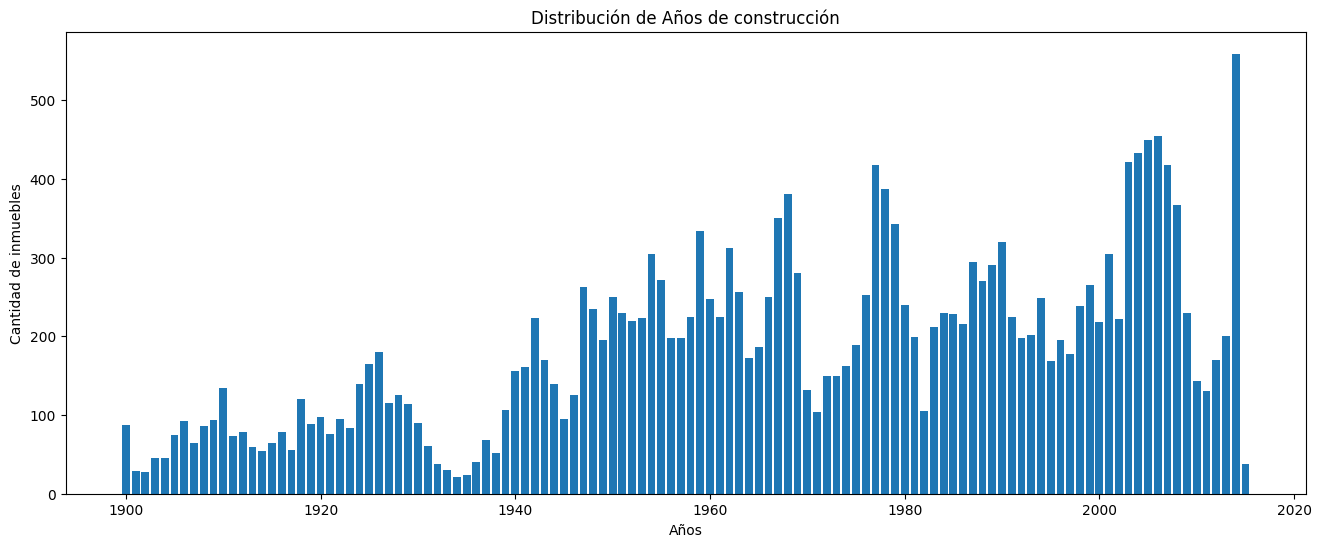

In [44]:
# Tamaño de la gráfica
plt.figure(figsize=(16,6))

# Cantidad de apariciones de cada año de construcción
plot_data = data['Años'].value_counts()

# Valores únicos (años) y sus frecuencias
x = plot_data.index
y = plot_data.values

# Gráfico de barras
plt.bar(x,y)

# Títulos de los ejes y del gráfico
plt.xlabel("Años")
plt.ylabel("Cantidad de inmuebles")
plt.title('Distribución de Años de construcción')

# Mostrar la gráfica
plt.show()

Esta gráfica muestra la distribución de los años de construcción de inmuebles. En el eje X se muestran los años en que fueron construidas, mientras que en el eje Y se observa la cantidad de casas que se construyeron en cada año. De esta forma podemos identificar patrones, como los periodos en donde se tuvo un aumento en la construcción o los años en donde se tuvieron menores edificaciones.

Adicionalmente, podemos crear otros tipos de gráficos, como **histogramas**, que muestran la frecuencia de aparición de valores numéricos dentro de intervalos continuos. Este gráfico nos ayuda a analizar la distribución de una variable.

Para ello, usamos la siguiente función adicional a las mencionadas anteriormente:

* `hist()`: Esta función establece que se renderizará un histograma, como parámetro usa la variable a graficar y el número de intervalos (bins) en los que se dividirán los datos.

#### Histograma — distribución de precios

El histograma es apropiado para `Precio` porque es una variable cuantitativa **continua**: agrupa valores en intervalos (`bins`) y muestra la frecuencia de cada intervalo.

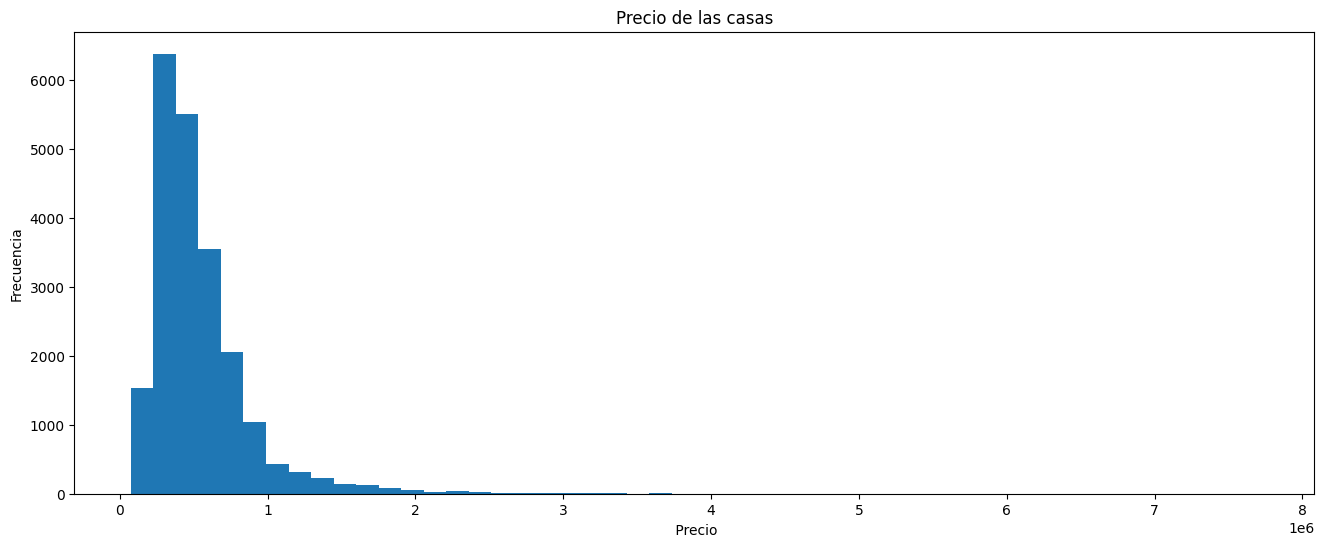

In [45]:
# Tamaño de la gráfica
plt.figure(figsize=(16,6))

# Variable a graficar
x = data['Precio']

# Histograma
plt.hist(x, bins=50)

# Títulos de los ejes y de la gráfica
plt.xlabel(" Precio")
plt.ylabel("Frecuencia")
plt.title('Precio de las casas')

# Mostrar gráfica
plt.show()

Este histograma muestra la distribución de los precios de las casas. En el eje X tenemos los valores de precio (que están divididos en 50 intervalos y cuya escala es en millones), mientras que en el eje Y se encuentra la frecuencia con la que aparecen los precios en el conjunto de datos. Este gráfico nos ayuda a entender que la mayor parte de las casas se encuentra en un precio inferior a un millón.

Otra gráfica que ofrece esta librería es de **líneas o puntos**, que nos permite observar relaciones entre dos variables. Por ejemplo, analizaremos la relación entre el número de baños y el precio. La función `plot()` recibe estos argumentos:

* `data['Baños]`: Los datos que tendrá el eje X.
* `data['Precio]`: Los datos que incluirá el eje Y.
* `.`: Establece el formato a usarse, en este caso de puntos. Pero también se pueden usar otros, como `*` para estrellas o `o` para círculos.
* `color='blue'`: Color que tendrá la gráfica.





#### Gráfico de dispersión — relación entre dos variables numéricas

Este tipo de gráfico muestra la relación entre dos variables cuantitativas. Cada punto representa un inmueble; su posición en X e Y indica los valores de las dos variables elegidas.

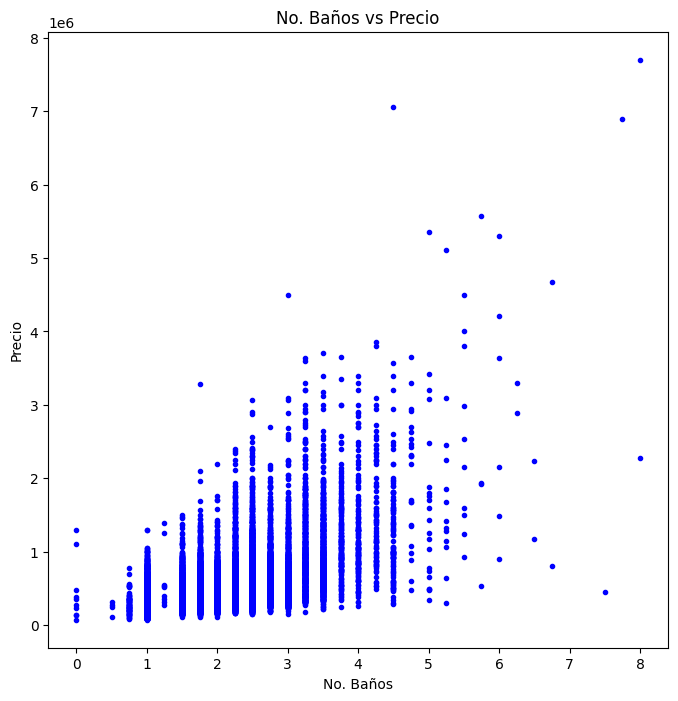

In [46]:
plt.figure(figsize=(8,8))

x = data['Baños']
y = data['Precio']

plt.plot(x, y, '.', color='blue')
plt.title('No. Baños vs Precio')
plt.xlabel('No. Baños')
plt.ylabel('Precio')
plt.show()

Este gráfico nos permite ver una tendencia, la cual es que a medida que aumenta el número de baños, el precio tiende a ser mayor. Sin embargo, la dispersión es considerable lo que nos da a entender que el número de baños no es el único factor determinante, sino que existen otros factores que también influenciaron en el precio.

Matplotlib también nos permite realizar gráficos de **pie**, los cuales permiten representar la proporción de cada categoría dentro de un conjunto de datos. Cada región del círculo corresponde a una categoría distinta y su tamaño refleja el porcentaje que ocupa respecto al total. Para realizar este gráfico necesitamos la función `pie()` que es la encargada de generar el gráfico circular. Sus parámetros principales son:

* `Valores numéricos`: Indican el tamaño de cada sector (por ejemplo, la frecuencia de cada categoría).
* `labels`: Define las etiquetas que se mostrarán en cada sector (por ejemplo, el número de habitaciones).
+ `autopct`: Muestra el porcentaje que representa cada categoría respecto al total.



#### Gráfico de torta — proporciones de una variable categórica

El gráfico de torta es adecuado para variables nominales con pocas categorías. Muestra qué proporción del total corresponde a cada categoría. En nuetro conjunto de datos solo tenemos FrenteMar.

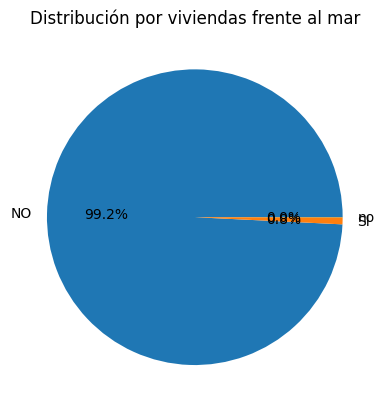

In [47]:
# Obtener el número de valores de cada categoría
categorias_count = data['FrenteMar'].value_counts()#.head(5)

# Función para ilustrar en forma de pie
plt.pie(categorias_count, labels=categorias_count.index, autopct='%1.1f%%')

# Título
plt.title('Distribución por viviendas frente al mar')

# Mostrar
plt.show()

Ten en cuenta que, aunque un pie puede utilizarse para variables con pocas categorías, no es recomendable cuando una de ellas representa una proporción muy pequeña del total. En estos casos, un gráfico de barras facilita la comparación y la lectura de las frecuencias.

#### Ejercicio

CConstruye un gráfico de barras que muestre el número promedio de cuartos para cada número de pisos de la vivienda. Para lograrlo necesitarás:
1. Agrupar el DataFrame por `Pisos` y calcular el promedio de `Cuartos` en cada grupo (pista: `groupby` + `mean()`).
2. Crear la figura con `plt.figure()`.
3. Dibujar las barras con `plt.bar()`, usando los valores de piso como eje X y el promedio de cuartos como altura.
4. Agregar título y etiquetas de ejes.
5. Mostrar el gráfico con `plt.show()`.

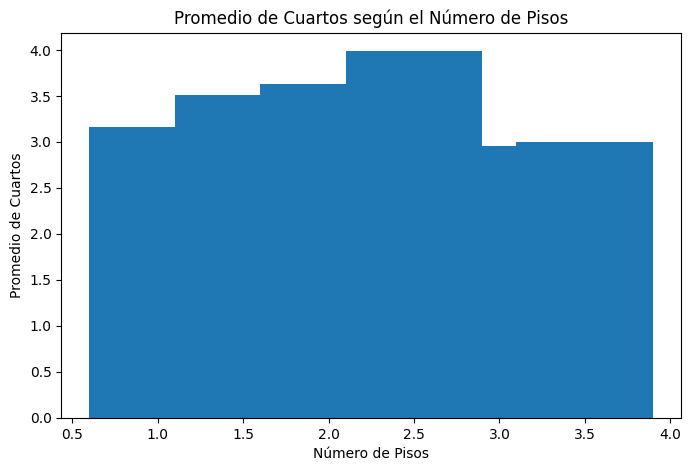

In [48]:
# TODO: Agrupa por 'Pisos' y calcula el promedio de 'Cuartos'
promedio_cuartos = data.groupby('Pisos')['Cuartos'].mean()

# TODO: Crea una nueva figura
plt.figure(figsize=(8, 5))

# TODO: Dibuja las barras usando el índice como categorías y los valores como alturas
plt.bar(promedio_cuartos.index, promedio_cuartos.values)

# TODO: Agrega un título diciente para el gráfico
plt.title('Promedio de Cuartos según el Número de Pisos')

# TODO: Nombra los ejes
plt.xlabel('Número de Pisos')
plt.ylabel('Promedio de Cuartos')

# TODO: Muestra el gráfico.
plt.show()




### Seaborn

Al igual que con Matplotlib, la librería Seaborn también nos ayuda a crear visualizaciones para entender mejor nuestro dataset. Para crear un **histograma** necesitamos la función `histplot()`, que requiere de estos parámetros:

* `data[Precio]`: Datos ubicados en el eje X.
* `kde=True`: Este argumento permite dibujar una curva para comprender mejor la distribución de la variable.


Seaborn es una librería de visualización construida sobre Matplotlib que ofrece gráficos estadísticos más elaborados con menos código. Sus principales ventajas son la integración directa con DataFrames de Pandas y la generación automática de curvas de densidad.

#### Histograma con curva de densidad (KDE)

`histplot()` es la versión Seaborn del histograma. El parámetro `kde=True` superpone una curva de estimación de densidad de kernel (KDE), que suaviza la distribución y facilita identificar la forma general (simétrica, sesgada a la derecha, bimodal, etc.).

<Axes: title={'center': 'Distribución del precio de las casas'}, xlabel=' Precio', ylabel='Frecuencia'>

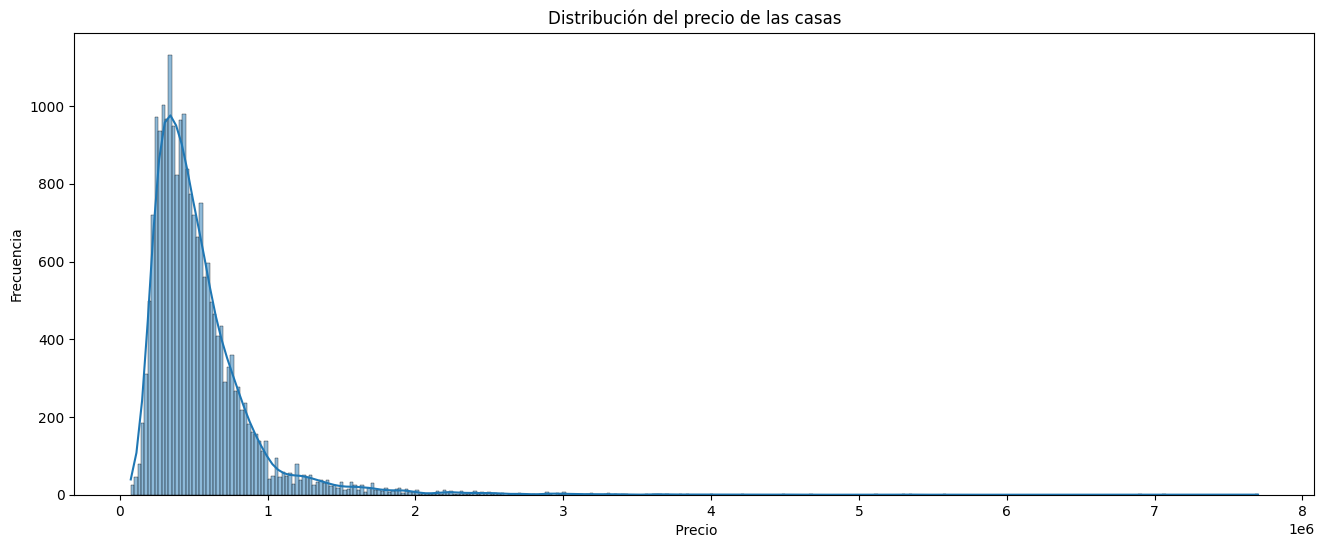

In [49]:
# Crear gráfica con esas dimensiones
plt.figure(figsize=(16,6))

# Datos a usar
x = data['Precio']

# Título
plt.xlabel(" Precio")
plt.ylabel("Frecuencia")
plt.title('Distribución del precio de las casas')

# Histograma
sns.histplot(x=data['Precio'], kde=True)

Podemos ver que obtuvimos una gráfica bastante similar a la que teníamos anteriormente con Matplotlib, solo que esta no está tan agrupada como esa. En caso de que quisiéramos que la gráfica fuera exactamente igual, solo deberíamos agregar un tercer parámetro a la función: `histplot` que sería `bins=50`, que referencia a los intervalos en los que queremos que se agrupen los datos.

#### Boxplot — distribución y valores atípicos

El **boxplot** (diagrama de caja) es ideal para visualizar la distribución de una variable cuantitativa continua y detectar valores atípicos (*outliers*). Su estructura es:

- **Caja**: abarca del cuartil Q1 al Q3 (el 50% central de los datos).
- **Línea interior**: mediana (Q2).
- **Bigotes**: se extienden hasta 1.5 × IQR desde la caja (IQR = Q3 − Q1).
- **Puntos fuera de los bigotes**: valores atípicos estadísticos.

<Axes: xlabel='AreaHabitable'>

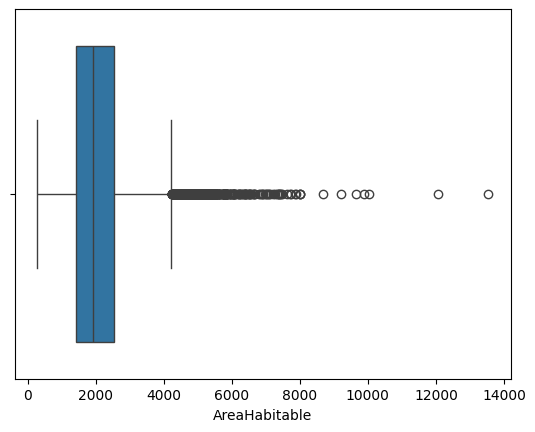

In [50]:
sns.boxplot(x=data['AreaHabitable'])

 La gráfica muestra un boxplot en donde la mayoría de las propiedades tienen un tamaño entre aproximadamente 1.400 y 2.500 pies cuadrados. La gráfica también permite ver que tiene una mediana cercana a 2.000 pies cuadrados. Otra observación importante es resaltar
 la gran cantidad de outliers extremos que superan los 4,000 pies cuadrados, llegando incluso a valores cercanos a 14.000 pies cuadrados. Esto indica que el dataset contiene propiedades atípicas (mansiones o haciendas) que podrían influir significativamente en análisis.

 Otra gráfica que podemos a utilizar es la de **JointGrid**, la cual combina un gráfico en el centro que muestra la relación entre dos variables con histogramas en los ejes, este permite ver la correlación entre dos variables como sus distribuciones. Lo cual resulta útil para analizar las concentraciones y los patrones que los datos muestran. La función que se usa es: `jointgrid()`.

#### JointGrid — relación entre dos variables con distribuciones marginales

El `JointGrid` combina en una sola figura:
- **Gráfico central**: muestra la relación conjunta entre dos variables (aquí como mapa de densidad).
- **Histogramas marginales** en los bordes: muestran la distribución individual de cada variable.

Es útil para explorar simultáneamente correlación y distribución.

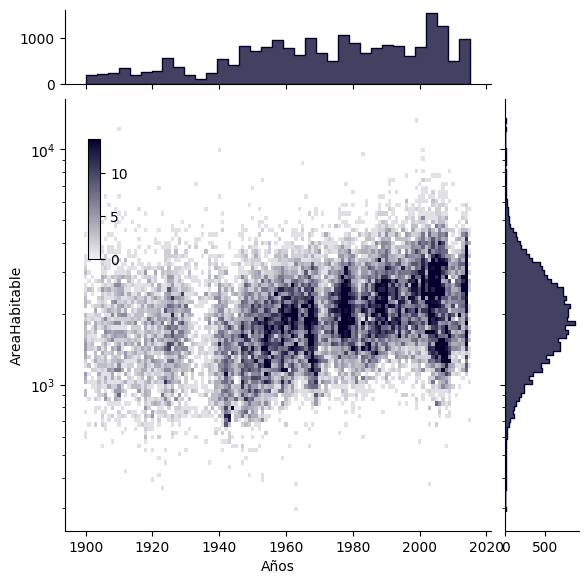

In [51]:
# Cargar los datos
g = sns.JointGrid(data=data, x="Años", y="AreaHabitable", marginal_ticks=True)

# Escala logaritmica
g.ax_joint.set(yscale="log")

# Leyenda para la barra de colores
cax = g.figure.add_axes([.15, .55, .02, .2])

# Agregar histograma articular y marginal
g.plot_joint(
    sns.histplot, discrete=(True, False),
    cmap="light:#03012d", pmax=.8, cbar=True, cbar_ax=cax
)
g.plot_marginals(sns.histplot, element="step", color="#03012d")

En el gráfico central, los colores indican la densidad de puntos, en donde las zonas más oscuras representan áreas con mayor concentración. Se observa que las casas más recientes tiendes a ser más grandes, ya que antes de 1960 predominan las áreas más pequeñas, mientras que después de la década de los 80s se tienen construcciones con áreas mayores. Mientras que también se puede observar que después del 2000, las áreas empiezan a bajar como generalidad, aunque también hay que mencionar que durante ese periodo se tienen datos con mayor área.

#### **Ejercicio**

Crea un **boxplot** que muestre la distribución de `Precio` agrupada por número de `Pisos`. Esto te permitirá ver si los inmuebles con más pisos tienden a tener precios más altos y qué tan dispersos son esos precios.

Para boxplot de Seaborn con dos variables usa: `sns.boxplot(x='variable_categorica', y='variable_numerica', data=df)`.

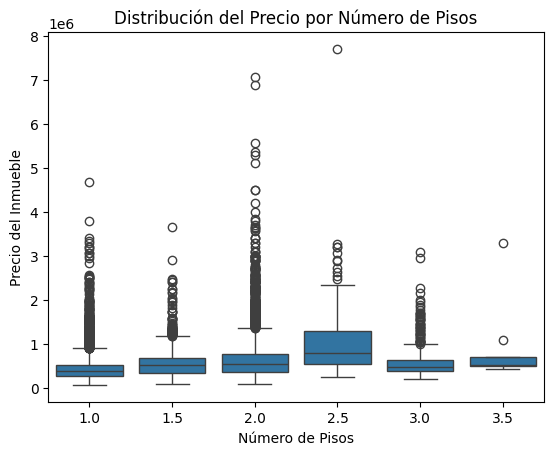

In [52]:
# TODO: Función boxplot con los datos de los ejes
sns.boxplot(x='Pisos', y='Precio', data=data)

# TODO: Título de la visualización
plt.title('Distribución del Precio por Número de Pisos')

# TODO: Nombre del eje X
plt.xlabel('Número de Pisos')

# TODO: Nombre del eje Y
plt.ylabel('Precio del Inmueble')

plt.show()


## 6. Calidad de datos

La calidad de los datos es uno de los factores más determinantes en el éxito de un proyecto de ML. Un modelo entrenado con datos de mala calidad producirá predicciones erróneas independientemente de qué tan sofisticado sea el algoritmo — es el principio de *garbage in, garbage out*.

Los errores en los datos pueden originarse por múltiples causas: mal funcionamiento de equipos, errores al registrar la información, información mal suministrada por el usuario, o integración de datos provenientes de fuentes distintas con formatos diferentes.

Los problemas de calidad más comunes se agrupan en cuatro dimensiones que analizaremos a continuación:

| Dimensión | Pregunta que responde |
|-----------|----------------------|
| **Completitud** | ¿Faltan datos? |
| **Unicidad** | ¿Hay registros duplicados? |
| **Consistencia** | ¿Los valores del mismo concepto están representados de forma uniforme? |
| **Validez** | ¿Los valores están dentro del rango permitido y tienen sentido en el contexto? |

> En este notebook identificamos los problemas de cada dimensión. Las estrategias de corrección (imputación, deduplicación, normalización, etc.) las exploraremos en un notebook posterior.

### Completitud

Es una dimensión en donde se mide el grado en el que un dataset contiene toda la información esperada, es decir que no tiene valores faltantes u omitidos.

La completitud mide el grado en que un dataset contiene toda la información esperada, es decir, que no tiene valores faltantes u omitidos (`NaN`, `None`, `null`).

En Pandas usamos `isnull().sum()` para contar los nulos por columna. Dividir por el total de filas nos da el **porcentaje de datos faltantes** por variable:

In [53]:
((data.isnull().sum()/data.shape[0])).sort_values(ascending=False)

,0
Calificación,0.000278
Fecha,0.000000
Precio,0.000000
Cuartos,0.000000
Id,0.000000
Baños,0.000000
AreaHabitable,0.000000
Pisos,0.000000
AreaLote,0.000000
FrenteMar,0.000000


Vemos que la única variable (columna) que tiene datos faltantes es `Calificación`.

Como primer acercamiento, veamos como son estos registros:

In [54]:
# Filtrar filas con Calificación nula
nulos = data[data['Calificación'].isna()].copy()

print(f"Filas con Calificación nula: {nulos.shape[0]}")
indices = data.index[data['Calificación'].isna()]
data[data['Calificación'].isna()].copy().reset_index(drop=True)

Filas con Calificación nula: 6


,Id,Fecha,Precio,Cuartos,Baños,AreaHabitable,AreaLote,Pisos,FrenteMar,Vista,...,Calificación,AreaSuperior,AreaBase,Años,Renovación,CodigoPostal,Latitud,Longitud,AreaHabitable15,AreaLote15
0,7853210060,20150406T000000,430000.0,4,2.50,2070,4310,2.0,NO,0,...,NaN,2070,0,2004,0,98065,475319.0,-121.85,1970,3748
1,3668000070,20150105T000000,212000.0,3,1.75,1060,7875,1.0,NO,0,...,NaN,1060,0,1986,0,98092,472761.0,-122152.00,1420,7680
2,2424000060,20140616T000000,500000.0,4,2.75,2280,15347,1.0,NO,0,...,NaN,2280,0,1960,0,98059,475218.0,-122164.00,2280,15347
3,3677400445,20140902T000000,475000.0,3,1.50,2480,5280,1.5,NO,0,...,NaN,1620,860,1947,0,98108,475575.0,-122303.00,2090,4800
4,2470100110,20140804T000000,5570000.0,5,5.75,9200,35069,2.0,NO,0,...,NaN,6200,3000,2001,0,98039,476289.0,-122233.00,3560,24345
5,1068000375,20140923T000000,3200000.0,6,5.00,7100,18200,2.5,NO,0,...,NaN,5240,1860,1933,2002,98199,476427.0,-122408.00,3130,6477


#### Ejercicio

1. ¿Qué porcentaje de los registros tiene `Calificación` nula? ¿Consideras que es un porcentaje relevante?
2. ¿Crees que los valores faltantes en `Calificación` podrían ser aleatorios (cualquier inmueble puede no tener calificación) o sistemáticos (solo cierto tipo de inmueble no tiene calificación)? ¿Qué implicación tiene cada caso para un modelo?

### Unicidad

Este atributo como su nombre lo sugiere indica que todos los registros están presentes una sola vez en el DataFrame, es decir, que no existen registros duplicados.

La unicidad verifica que cada registro aparece exactamente una vez en el dataset. Existen dos tipos de duplicados a revisar:

1. **Filas idénticas**: todas las columnas son iguales entre dos registros.
2. **Duplicados lógicos**: filas que no son idénticas pero representan la misma entidad según la lógica del negocio (e.g., mismo `Id` con datos distintos).

Primero revisamos filas completamente idénticas con `duplicated()`:

In [55]:
int(data.duplicated(keep=False).sum())

0

Podemos ver que no existen registros duplicados. Esto nos dice que no hay una fila que sea exactamente igual a otra.

Pero podemos ir más allá, y ver si hay más de un registro con el mismo id, el cual debería ser único para cada dato:

In [56]:
# ids duplicados
dup_counts = (data['Id'].value_counts()
                        .loc[lambda s: s > 1]
                        .sort_values(ascending=False))
for id_, n in dup_counts.items():
    print(f"Id={id_} → {n} apariciones")

Id=795000620 → 3 apariciones
Id=7520000695 → 2 apariciones
Id=7200179 → 2 apariciones
Id=3904100089 → 2 apariciones
Id=6308000010 → 2 apariciones
Id=8945100320 → 2 apariciones
Id=3739500096 → 2 apariciones
Id=7888000390 → 2 apariciones
Id=5332200530 → 2 apariciones
Id=2568300045 → 2 apariciones
Id=3333002450 → 2 apariciones
Id=8648900110 → 2 apariciones
Id=4222310010 → 2 apariciones
Id=3293700496 → 2 apariciones
Id=3883800011 → 2 apariciones
Id=3558900590 → 2 apariciones
Id=7972000010 → 2 apariciones
Id=2619920170 → 2 apariciones
Id=7520000520 → 2 apariciones
Id=9353300600 → 2 apariciones
Id=7504021310 → 2 apariciones
Id=123039336 → 2 apariciones
Id=4204400098 → 2 apariciones
Id=4443800385 → 2 apariciones
Id=1788900230 → 2 apariciones
Id=8129700644 → 2 apariciones
Id=722039087 → 2 apariciones
Id=8121100395 → 2 apariciones
Id=8645530010 → 2 apariciones
Id=3271300955 → 2 apariciones
Id=3332000615 → 2 apariciones
Id=1974300020 → 2 apariciones
Id=6300000226 → 2 apariciones
Id=6632900574 → 

Podemos ver que existen muchos ids compartidos por más de un registro, lo cual puede representar un problema, ya que el id, en principio, debería ser un identificador único para cada inmueble. Por lo que podemos profundizar y ver como están compuestos esos registros con id compartido.

In [57]:
# Detalle de los registros
dup_table = (
    data[data['Id'].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=data.groupby('Id')['Id'].transform('size'))
    .sort_values(['repeticiones', 'Id'], ascending=[False, True])
)

# Mostrar tabla
dup_table

,Id,Fecha,Precio,Cuartos,Baños,AreaHabitable,AreaLote,Pisos,FrenteMar,Vista,...,AreaSuperior,AreaBase,Años,Renovación,CodigoPostal,Latitud,Longitud,AreaHabitable15,AreaLote15,repeticiones
17602,795000620,20140924T000000,115000.0,3,1.0,1080,6250,1.0,NO,0,...,1080,0,1950,0,98168,475045.0,-122.33,1070,6250,3
17603,795000620,20141215T000000,124000.0,3,1.0,1080,6250,1.0,NO,0,...,1080,0,1950,0,98168,475045.0,-122.33,1070,6250,3
17604,795000620,20150311T000000,157000.0,3,1.0,1080,6250,1.0,NO,0,...,1080,0,1950,0,98168,475045.0,-122.33,1070,6250,3
2496,1000102,20140916T000000,280000.0,6,3.0,2400,9373,2.0,NO,0,...,2400,0,1991,0,98002,473262.0,-122214.00,2060,7316,2
2497,1000102,20150422T000000,300000.0,6,3.0,2400,9373,2.0,NO,0,...,2400,0,1991,0,98002,473262.0,-122214.00,2060,7316,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6346,9828200460,20150106T000000,430000.0,2,1.0,700,4800,1.0,NO,0,...,700,0,1922,0,98122,476147.0,-122.30,1440,4800,2
15199,9834200305,20140716T000000,350000.0,3,1.0,1790,3876,1.5,NO,0,...,1090,700,1904,0,98144,47575.0,-122288.00,1360,4080,2
15200,9834200305,20150210T000000,615000.0,3,1.0,1790,3876,1.5,NO,0,...,1090,700,1904,0,98144,47575.0,-122288.00,1360,4080,2
1085,9834200885,20140717T000000,360000.0,4,2.5,2080,4080,1.0,NO,0,...,1040,1040,1962,0,98144,47572.0,-122.29,1340,4080,2


#### Ejercicio

Observando la tabla anterior, ¿qué hipótesis puedes plantear para explicar por qué un mismo `Id` aparece más de una vez con datos distintos? Menciona al menos dos posibilidades.

In [58]:
# Escribe tus hipótesis como comentarios:
# Hipótesis 1:Como se puede observar en la tabla, cuestiones tales como las características físicas de la casa como área, cuartos y localización
#             se mantienen constantes, pero si en lugar de las anteriores 'Fecha' y 'Precio', pusiéramos las variables 'Fecha' y 'PrecModal', éstas
#             síntomas y 'Precio', éstas se manifiestan con variación. Esto nos puede indicar y reflejar que el conjunto de datos, es un conjunto datario
#             longitudinal donde la misma vivienda se ha vendido en más de una ocasión en el tiempo.
# Hipótesis 2:La propiedad se pudo haber re-publicado en el mercado inmobiliario tras una compra previa, o haber sufrido una actualización de
#             precio por parte del vendedor/agencia en una fecha posterior en relación a la valorización del sector.

### Consistencia
Este proceso se basa en tener coherencia entre los diferentes valores de la columna. Es decir, que no se tengan diferentes cadenas o números que representen la misma categoría en una columna con valores categóricos. Como lo vimos anteriormente gracias a la función `.info()` solo tenemos una variable en formato `object`, por lo que es está la que vamos a analizar, con el fin de ver si se tiene más de un tipo para representar lo mismo.

La consistencia verifica que los valores que representan el mismo concepto estén codificados de forma uniforme en todo el dataset. Los problemas más comunes son:

- **Inconsistencia de formato en texto**: `'NO'` vs. `'no'` vs. `'No'` para la misma categoría.
- **Inconsistencia entre columnas**: dos columnas que deberían ser equivalentes (e.g., peso en kg y peso en libras) tienen valores contradictorios.
- **Inconsistencia entre filas**: el mismo campo tiene formatos distintos en registros diferentes (e.g., fechas escritas como `'2023-01-15'` y `'15/01/2023'`).

Revisemos la columna `FrenteMar`, que es de tipo `object`:

In [59]:
data['FrenteMar'].value_counts()

,count
FrenteMar,
NO,21446
SI,163
no,4


Este es el caso, como vemos tanto la cadena `NO` como la de `no` representan lo mismo, lo que significa un error de consistencia ya que tenemos más de una cadena para la misma información.

#### Ejercicio

1. ¿Cuántas categorías distintas tiene `FrenteMar` y cuáles son? ¿Cuántas debería tener?
2. Si un modelo de ML recibe esta columna sin corregir, ¿cómo la interpretaría? ¿Qué consecuencia tendría eso en sus predicciones?

In [62]:
# TODO: Punto 1
# La columna tiene 3 categorías distintas, las cuales son 'NO', 'SI' y 'no'.
# Debería tener únicamente 2 categorías, correspondientes a una variable binaria estandarizada (Sí o No).

print("Valores únicos en FrenteMar:")
print(data['FrenteMar'].value_counts())

# TODO: Punto 2 — responde como comentario:
# El modelo interpretaría las cadenas 'NO' y 'no' como dos categorías bien diferenciadas -la una de la otra- y, a su vez,
# independientes la una de la otra, por tanto aplicar la codificación del tipo One-Hot Encoding.
# La consecuencia sería una pérdida de precisión y sesgo en las predicciones, puesto que los 4 registros de 'no' pasarían
# a ser un grupo aislado y raro, tal que el modelo no los logra disponer en su verdadera identificación a la de (sin vista al mar).

Valores únicos en FrenteMar:
FrenteMar
NO    21446
SI      163
no        4
Name: count, dtype: int64


### Validez

Esta dimensión considera la exactitud y veracidad de la información, asegurando que los datos midan lo que se supone que deben medir y que sean correctos y coherentes. Es decir, que el valor que se tiene está dentro de los valores posibles.

La validez verifica que los valores de cada columna están dentro del rango esperado y tienen sentido en el contexto del problema. A diferencia de la consistencia (que es un problema de formato), la validez es un problema de contenido: el dato puede estar bien formateado pero ser incorrecto.

Dos tipos frecuentes de problemas de validez:
1. **Valores fuera del rango definido**: e.g., una calificación que puede ir de 1 a 13 pero aparece como 99.
2. **Valores atípicos**: estadísticamente extremos, pueden ser correctos (una mansión de 50 cuartos existe) o errores de captura. El boxplot de la sección anterior es una herramienta útil para detectarlos.

Usamos `describe()` y comparamos con el diccionario de datos para detectar valores fuera de rango:

In [63]:
data.describe()

,Id,Precio,Cuartos,Baños,AreaHabitable,AreaLote,Pisos,Vista,Condición,Calificación,AreaSuperior,AreaBase,Años,Renovación,CodigoPostal,Latitud,Longitud,AreaHabitable15,AreaLote15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21607.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401822e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.247397,3.409430,7.656500,1788.390691,291.509045,1971.005136,84.402258,98077.939805,430610.744655,-109898.947043,1986.552492,12768.455652
std,2.876566e+09,3.673622e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,1.100329,0.650743,1.174463,828.090978,442.575043,29.373411,401.679240,53.505026,132157.751849,36768.975764,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,-3.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.190000,-122519.000000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,473849.000000,-122318.000000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,475524.000000,-122205.000000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,476694.000000,-122062.000000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,44.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,477776.000000,-121.480000,6210.000000,871200.000000


Gracias a la función `.describe()` podemos ver que se tienen valores fuera del rango para la columna `Vista`, el diccionario menciona que el rango va de $[0,4]$ pero podemos ver que el valor mínimo es $-3$ y el valor máximo es $44$ lo cual no coincide con los valores que debería tomar, representando un problema de Validez.


#### Ejercicio

1. Revisa el `describe()` anterior. ¿Hay alguna otra columna que tenga valores fuera de un rango razonable? Pista: revisa `Cuartos` y `Baños`.
2. ¿Cómo distinguirías un valor atípico que es un error de captura de uno que es un dato real pero inusual?

In [65]:
# TODO: Punto 1: revisa Cuartos y Baños
print(data[['Cuartos', 'Baños']].describe())
# ¿Qué valores te parecen sospechosos?
# - En 'Cuartos': El máximo de 33 cuartos (desproporcionado frente a la media de 3.37) y el mínimo de 0 cuartos.
# - En 'Baños': El mínimo de 0 baños (poco realista para una vivienda residencial).

# TODO: Punto 2 — responde como comentario:
# Para diferenciar un error de captura de un dato real inusual se puede observar la relación del valor atípico
# con el resto de las variables de la fila, y evaluar si el valor atípico infringe restricciones físicas del
# espacio del dominio o si el dato resulta débil desmedido con respecto al total de la propiedad, como marcar 33
# habitaciones por error en vez de 3.3 o 3. Se clasificaría como error de entrada, en tanto que si el valor atípico
# guarda proporcionalidad con la superficie y el precio (como un palacio o mansión real), se clasificaría como un dato real poco frecuente.

            Cuartos         Baños
count  21613.000000  21613.000000
mean       3.370842      2.114757
std        0.930062      0.770163
min        0.000000      0.000000
25%        3.000000      1.750000
50%        3.000000      2.250000
75%        4.000000      2.500000
max       33.000000      8.000000


### 7. Formato automático para el entendimiento de los datos

Todo el proceso de entendimiento de datos que hemos realizadp a través de este notebook, se puede complementar con un reporte automático, el cual usa herramientas de pandas profiling.

Para cada variable del DataFrame genera las siguientes estadísticas:

1. Variables: Identifica todas las columnas que tiene el DataFrame.
2. Información importante: Muestra el tipo, valores únicos, valores faltantes.
3. Estadísticas: Refleja información importante como el valor mínimo, el máximo, número de valores que son cero, número de valores distintos (muy útil para ver si los ids solo están asociados a un registro) y faltantes (para ver si se cumple con la completitud).
4. Valores a considerar: Muestra los valores que más se repiten en una columna, estadísticas descriptivas y de cuartil, al igual que valores extremos.
5. Histogramas.

Tomado de la librería oficial de pandas_profiling en [github](https://github.com/pandas-profiling/pandas-profiling)

Lo más importante al utilizar esta librería es recordar que lo fundamental son los análisis que hagamos sobre estos reportes.

In [66]:
%pip install --user fg-data-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.3/400.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.1 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Para verificar que se hizo la instalación correctamente, puedes utilizar:

In [67]:
%pip show fg-data-profiling

Name: fg-data-profiling
Version: 4.19.1
Summary: Generate profile report for pandas DataFrame
Home-page: https://ydata.ai
Author: 
Author-email: YData Labs Inc <opensource@ydata.ai>
License: 
Location: /root/.local/lib/python3.12/site-packages
Requires: dacite, filetype, imagehash, jinja2, matplotlib, minify-html, multimethod, numba, numpy, pandas, phik, pydantic, PyYAML, requests, scipy, seaborn, statsmodels, tqdm, typeguard, visions, wordcloud
Required-by: 


In [70]:
from data_profiling import ProfileReport

ModuleNotFoundError: No module named 'data_profiling'

In [ ]:
profile = ProfileReport(
    data,
    title="Reporte de Análisis Exploratorio",
    explorative=True
)

In [ ]:
profile.to_notebook_iframe()

In [ ]:
profile.to_file("reporte_analisis_exploratorio.html")

## ¿Qué aprendimos?

En este notebook aprendiste a cargar y manipular un conjunto de datos utilizando Pandas, interpretar la información proporcionada por el diccionario de datos y distinguir entre el tipo técnico de las columnas y el tipo estadístico de las variables. Además, realizaste un análisis exploratorio para comprender la estructura y distribución de los datos, e identificaste algunas dimensiones básicas de la calidad de los datos, como valores faltantes, registros duplicados, inconsistencias y valores fuera del dominio esperado. Estas actividades constituyen una etapa fundamental en cualquier proyecto de aprendizaje de máquina, ya que permiten comprender mejor los datos disponibles y detectar posibles problemas antes de construir un modelo predictivo.